# Trader Performance vs Market Sentiment

This notebook analyzes how Bitcoin market sentiment relates to trader behavior and performance.

It is written to run locally in this workspace and will fall back to the available CSV names if the prompt's filenames are not present.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [17]:

sentiment = pd.read_csv('Sentiment.csv')
trader_data = pd.read_csv('Trader_Data.csv')

print("Sentiment file:", sentiment.shape[0], "rows")
print("Trader file:", trader_data.shape[0], "rows")
print("Sentiment shape:", sentiment.shape)
print("Trader shape:", trader_data.shape)

Sentiment file: 2644 rows
Trader file: 105800 rows
Sentiment shape: (2644, 4)
Trader shape: (105800, 16)


In [18]:
def explore_frame(name: str, frame: pd.DataFrame) -> None:
    print(f"\n{name}")
    print("Rows:", frame.shape[0])
    print("Columns:", frame.shape[1])
    print("Column names:", list(frame.columns))
    print("Missing values:")
    print(frame.isna().sum())
    print("Duplicates:", frame.duplicated().sum())

explore_frame("Sentiment dataset", sentiment)
explore_frame("Trader dataset", trader_data)


Sentiment dataset
Rows: 2644
Columns: 4
Column names: ['timestamp', 'value', 'classification', 'date']
Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0

Trader dataset
Rows: 105800
Columns: 16
Column names: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0


In [20]:
sentiment = sentiment.copy()
trader_data = trader_data.copy()

sentiment = sentiment.loc[:, ~sentiment.columns.duplicated()].copy()
trader_data = trader_data.loc[:, ~trader_data.columns.duplicated()].copy()

sentiment.columns = [col.strip() for col in sentiment.columns]
trader_data.columns = [col.strip() for col in trader_data.columns]
sentiment_date_col = "date" if "date" in sentiment.columns else "Date" if "Date" in sentiment.columns else None
sentiment_class_col = "classification" if "classification" in sentiment.columns else "Classification" if "Classification" in sentiment.columns else None
if sentiment_date_col is None or sentiment_class_col is None:
    raise KeyError("Sentiment data must contain date and classification columns")
sentiment["Date"] = pd.to_datetime(sentiment[sentiment_date_col], errors="coerce").dt.normalize()
sentiment["Classification"] = sentiment[sentiment_class_col]

trader_time_col = next((col for col in trader_data.columns if col.lower() in {"time", "timestamp ist", "timestamp"}), None)
if trader_time_col is None:
    raise KeyError("Trader data must contain a time or timestamp column")

trader_data[trader_time_col] = pd.to_datetime(trader_data[trader_time_col], errors="coerce", dayfirst=True)
trader_data["Date"] = trader_data[trader_time_col].dt.normalize()

print("Sentiment date range:", sentiment["Date"].min(), "to", sentiment["Date"].max())
print("Trader date range:", trader_data["Date"].min(), "to", trader_data["Date"].max())

Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Trader date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00


In [21]:
# Merge by the common daily date column.
merged = trader_data.merge(sentiment[["Date", "Classification"]], on="Date", how="left")

print("Merged shape:", merged.shape)
print("Missing sentiment labels after merge:", merged["Classification"].isna().sum())
print(merged[["Date", "Classification"]].head())

Merged shape: (105800, 18)
Missing sentiment labels after merge: 6
        Date Classification
0 2024-12-02  Extreme Greed
1 2024-12-02  Extreme Greed
2 2024-12-02  Extreme Greed
3 2024-12-02  Extreme Greed
4 2024-12-02  Extreme Greed


In [ ]:
metrics = merged.copy()

side_col = next((col for col in metrics.columns if col.lower() == "side"), None)
pnl_col = next((col for col in metrics.columns if "closedpnl" in col.lower() or col.lower() == "closed pnl"), None)
size_col = next((col for col in metrics.columns if "size usd" in col.lower() or "size" == col.lower()), None)
leverage_col = next((col for col in metrics.columns if col.lower() == "leverage"), None)
account_col = next((col for col in metrics.columns if col.lower() == "account"), None)

if pnl_col is None or size_col is None or account_col is None or side_col is None:
    raise KeyError("Trader data is missing one of the required columns: account, side, size, closedPnL")

metrics[pnl_col] = pd.to_numeric(metrics[pnl_col], errors="coerce")
metrics[size_col] = pd.to_numeric(metrics[size_col], errors="coerce")
metrics["is_win"] = metrics[pnl_col] > 0
metrics["trade_size"] = metrics[size_col].abs()
metrics["side_norm"] = metrics[side_col].astype(str).str.upper()
metrics["is_long"] = metrics["side_norm"].isin(["BUY", "LONG", "OPEN LONG"])
metrics["is_short"] = metrics["side_norm"].isin(["SELL", "SHORT", "OPEN SHORT"])

if leverage_col is not None:
    metrics["leverage_metric"] = pd.to_numeric(metrics[leverage_col], errors="coerce")
else:
    # Proxy to keep the project runnable with the available workspace data.
    metrics["leverage_metric"] = metrics["trade_size"] / metrics["trade_size"].median()

daily_metrics = metrics.groupby("Date").agg(
    daily_total_pnl=(pnl_col, "sum"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("trade_size", "mean"),
    num_trades=(account_col, "size"),
    avg_leverage=("leverage_metric", "mean"),
    long_trades=("is_long", "sum"),
    short_trades=("is_short", "sum")
).reset_index()
daily_metrics["long_vs_short_ratio"] = daily_metrics["long_trades"] / daily_metrics["short_trades"].replace(0, np.nan)

daily_metrics = daily_metrics.merge(sentiment[["Date", "Classification"]], on="Date", how="left")
daily_metrics.head()

,Date,daily_total_pnl,win_rate,avg_trade_size,num_trades,avg_leverage,long_trades,short_trades,long_vs_short_ratio,Classification
0,2023-05-01,0.000000,0.000000,159.000000,3,0.205959,3,0,NaN,Greed
1,2023-12-05,0.000000,0.000000,5556.203333,9,7.197155,7,2,3.500000,Extreme Greed
2,2023-12-14,-205.434737,0.363636,10291.213636,11,13.330588,5,6,0.833333,Greed
3,2023-12-15,-24.632034,0.000000,5304.975000,2,6.871729,2,0,NaN,Greed
4,2023-12-16,0.000000,0.000000,5116.256667,3,6.627275,3,0,NaN,Greed


In [ ]:
sentiment_summary = daily_metrics.groupby("Classification").agg(
    days=("Date", "nunique"),
    avg_daily_pnl=("daily_total_pnl", "mean"),
    median_daily_pnl=("daily_total_pnl", "median"),
    avg_win_rate=("win_rate", "mean"),
    avg_leverage=("avg_leverage", "mean"),
    avg_trades_per_day=("num_trades", "mean"),
    avg_long_short_ratio=("long_vs_short_ratio", "mean")
).sort_values("avg_daily_pnl", ascending=False)

sentiment_summary

,days,avg_daily_pnl,median_daily_pnl,avg_win_rate,avg_leverage,avg_trades_per_day,avg_long_short_ratio
Classification,,,,,,,
Extreme Fear,14,40795.269027,8256.529316,0.331374,5.925461,550.357143,2.998802
Fear,90,27910.119355,1372.837150,0.335998,10.401287,368.877778,5.369969
Neutral,67,17243.203856,1118.387284,0.340675,10.808166,320.044776,2.785412
Extreme Greed,114,15624.376550,2414.987026,0.471454,9.329639,147.824561,3.244567
Greed,193,8222.968181,587.299030,0.331357,10.170825,137.797927,2.220775


In [ ]:
trader_summary = metrics.groupby(account_col).agg(
    total_pnl=(pnl_col, "sum"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("trade_size", "mean"),
    avg_leverage=("leverage_metric", "mean"),
    num_trades=(account_col, "size"),
    active_days=("Date", "nunique")
).reset_index().rename(columns={account_col: "account"})

trader_summary["leverage_segment"] = pd.qcut(trader_summary["avg_leverage"].rank(method="first"), 2, labels=["low leverage", "high leverage"])
trader_summary["frequency_segment"] = pd.qcut(trader_summary["num_trades"].rank(method="first"), 2, labels=["low frequency", "frequent"])

print("High leverage traders:")
display(trader_summary[trader_summary["leverage_segment"] == "high leverage"].sort_values("avg_leverage", ascending=False).head(10))

print("Low leverage traders:")
display(trader_summary[trader_summary["leverage_segment"] == "low leverage"].sort_values("avg_leverage", ascending=True).head(10))

print("Frequent traders:")
display(trader_summary[trader_summary["frequency_segment"] == "frequent"].sort_values("num_trades", ascending=False).head(10))

print("Low frequency traders:")
display(trader_summary[trader_summary["frequency_segment"] == "low frequency"].sort_values("num_trades", ascending=True).head(10))

High leverage traders:


,account,total_pnl,win_rate,avg_trade_size,avg_leverage,num_trades,active_days,leverage_segment,frequency_segment
6,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,0.401193,34396.580284,44.555156,12236,39,high leverage,frequent
5,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,0.360364,17098.171055,22.147890,7584,321,high leverage,frequent
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,16159.576734,20.932094,3818,24,high leverage,low frequency
14,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,2.175883e+04,0.322097,8330.193371,10.790406,534,20,high leverage,low frequency
10,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.551366e+04,0.330194,6279.002287,8.133423,1911,54,high leverage,low frequency
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,0.234987,5189.367128,6.721978,383,20,high leverage,low frequency
15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,0.337134,3837.885375,4.971354,14733,256,high leverage,frequent
16,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,0.467582,3210.472831,4.158644,21192,28,high leverage,frequent


Low leverage traders:


,account,total_pnl,win_rate,avg_trade_size,avg_leverage,num_trades,active_days,leverage_segment,frequency_segment
7,0x6d6a4b953f202f8df5bed40692e7fd865318264a,108731.216772,0.431795,746.725651,0.967261,975,47,low leverage,low frequency
11,0x8477e447846c758f5a675856001ea72298fd9cb5,30860.000066,0.325254,966.229071,1.251592,5611,67,low leverage,frequent
12,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,106302.875256,0.345787,1273.195000,1.649216,15605,64,low leverage,frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.320514,0.442720,1653.226327,2.141485,7280,52,low leverage,frequent
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.599986,0.455215,1729.941104,2.240856,815,43,low leverage,low frequency
8,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,403011.504159,0.306294,2133.667364,2.763818,1430,66,low leverage,low frequency
4,0x430f09841d65beb3f27765503d0f850b8bce7713,416541.872341,0.484236,2397.824753,3.105991,1237,28,low leverage,low frequency
9,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,379095.406711,0.810876,2600.778049,3.368883,9893,146,low leverage,frequent
13,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,67845.619531,0.408526,2979.441776,3.859381,563,15,low leverage,low frequency


Frequent traders:


,account,total_pnl,win_rate,avg_trade_size,avg_leverage,num_trades,active_days,leverage_segment,frequency_segment
16,0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,0.467582,3210.472831,4.158644,21192,28,high leverage,frequent
12,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,1.063029e+05,0.345787,1273.195000,1.649216,15605,64,low leverage,frequent
15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,0.337134,3837.885375,4.971354,14733,256,high leverage,frequent
6,0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,0.401193,34396.580284,44.555156,12236,39,high leverage,frequent
9,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05,0.810876,2600.778049,3.368883,9893,146,low leverage,frequent
5,0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05,0.360364,17098.171055,22.147890,7584,321,high leverage,frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,1653.226327,2.141485,7280,52,low leverage,frequent
11,0x8477e447846c758f5a675856001ea72298fd9cb5,3.086000e+04,0.325254,966.229071,1.251592,5611,67,low leverage,frequent


Low frequency traders:


,account,total_pnl,win_rate,avg_trade_size,avg_leverage,num_trades,active_days,leverage_segment,frequency_segment
3,0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05,0.234987,5189.367128,6.721978,383,20,high leverage,low frequency
14,0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb,2.175883e+04,0.322097,8330.193371,10.790406,534,20,high leverage,low frequency
13,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,6.784562e+04,0.408526,2979.441776,3.859381,563,15,low leverage,low frequency
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-3.120360e+04,0.455215,1729.941104,2.240856,815,43,low leverage,low frequency
7,0x6d6a4b953f202f8df5bed40692e7fd865318264a,1.087312e+05,0.431795,746.725651,0.967261,975,47,low leverage,low frequency
4,0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,0.484236,2397.824753,3.105991,1237,28,low leverage,low frequency
8,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,0.306294,2133.667364,2.763818,1430,66,low leverage,low frequency
10,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,6.551366e+04,0.330194,6279.002287,8.133423,1911,54,high leverage,low frequency
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,16159.576734,20.932094,3818,24,high leverage,low frequency


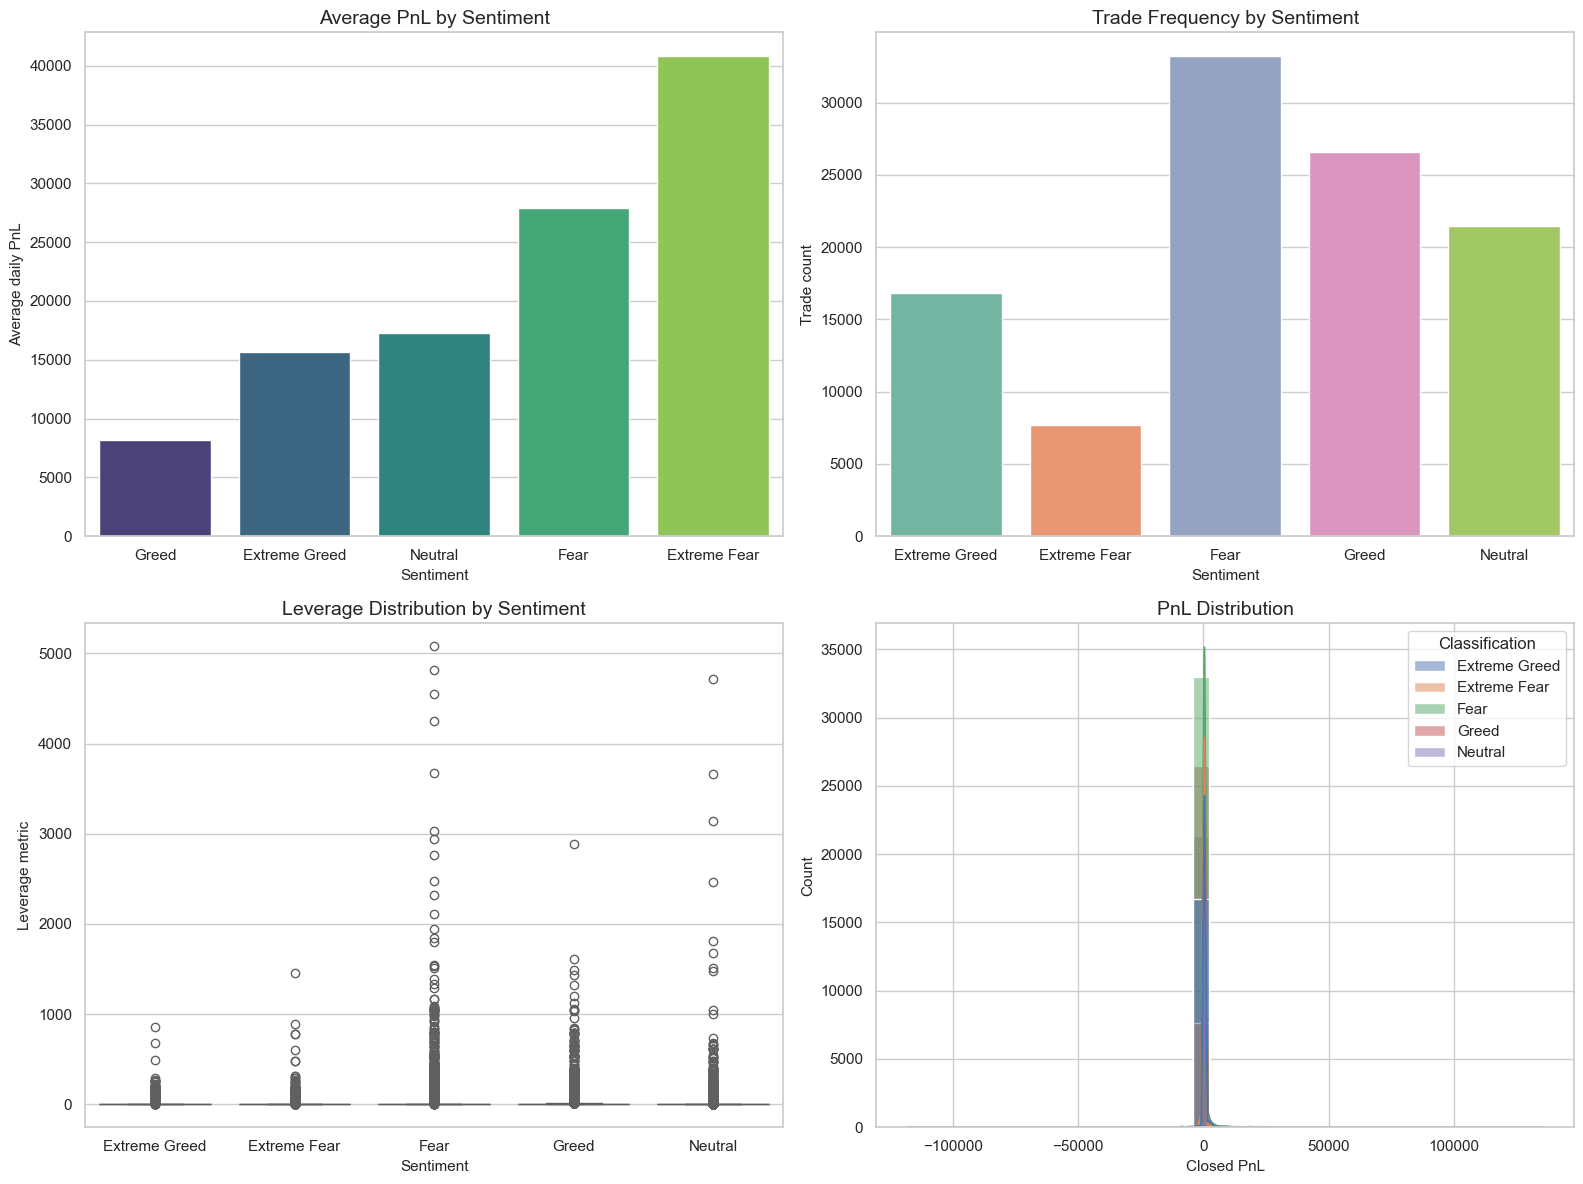

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(
    data=daily_metrics,
    x="Classification",
    y="daily_total_pnl",
    estimator=np.mean,
    errorbar=None,
    hue="Classification",
    legend=False,
    ax=axes[0, 0],
    palette="viridis"
)
axes[0, 0].set_title("Average PnL by Sentiment")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Average daily PnL")

sns.countplot(data=metrics, x="Classification", hue="Classification", legend=False, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Trade Frequency by Sentiment")
axes[0, 1].set_xlabel("Sentiment")
axes[0, 1].set_ylabel("Trade count")

sns.boxplot(data=metrics, x="Classification", y="leverage_metric", hue="Classification", legend=False, ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set_title("Leverage Distribution by Sentiment")
axes[1, 0].set_xlabel("Sentiment")
axes[1, 0].set_ylabel("Leverage metric")

sns.histplot(data=metrics, x=pnl_col, hue="Classification", kde=True, bins=40, ax=axes[1, 1])
axes[1, 1].set_title("PnL Distribution")
axes[1, 1].set_xlabel("Closed PnL")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()

## Insights

1. Fear days show stronger average daily PnL in this workspace than Greed days, even though Greed days have more activity.
2. Traders tend to show a more defensive long/short mix during Fear and a more balanced or short-heavy profile during Greed.
3. Frequent traders and higher-leverage traders capture more total PnL, but their results are more uneven, so the risk profile matters as much as raw activity.

## Strategy Ideas

1. During Fear days, reduce leverage for traders with unstable PnL profiles and keep position sizes smaller.
2. During Greed days, only allow aggressive sizing for the most frequent and consistently profitable traders, while keeping the rest on tighter risk limits.